# 08 · Attention: 점수로 읽을 위치를 정하고 값을 섞기

**이번 질문:** 모든 과거를 하나의 상태에 압축하는 대신, 현재 질문과 각 입력을 비교해서 필요한 정보를 읽을 수 있을까요?

06·07번은 과거를 상태 하나에 눌러 담았습니다. 이번에는 질문(Q)과 각 항목의 특징(K)을 내적으로 비교해 점수를 매기고, softmax로 합이 1인 가중치를 만든 뒤, 그 비율로 내용(V)을 섞어 읽습니다.
Q·K·V → scaled dot-product → softmax 미분 → mask → 검색 학습을 구현합니다. Attention 계산 부품을 먼저 완성하고, 다음 09에서 Transformer 구조로 조합합니다.

- 준비물: [00](../00_기초/00_math_to_numpy.ipynb)의 행렬곱·전치, [02](../00_기초/02_probability_and_losses.ipynb)의 softmax·CE, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 affine backward.
- 도착점: attention의 forward·backward를 직접 쓰고 mask까지 검산한 뒤, "query가 가리키는 key의 값"을 찾는 작은 검색 문제를 학습시킵니다.
- 다음 연결: [09 Transformer](09_transformer.ipynb)는 이 부품에 위치·잔차·정규화·FFN을 붙여 블록으로 쌓습니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. attention은 세 줄입니다. 점수 `S = Q @ K.swapaxes(-1, -2) / sqrt(d_k)`, 가중치 `P = softmax(S)` (**key 축**에서 합 1), 읽기 `O = P @ V`. 3차원 배열의 `@`는 배치마다 마지막 두 축을 곱합니다.
2. softmax의 backward는 원소별이 아닙니다. 분모를 모든 위치가 공유하므로 `dS = P * (dP - (dP * P).sum(axis=-1, keepdims=True))`. sigmoid처럼 `p(1-p)`만 곱하면 다른 위치의 기여가 빠집니다.
3. mask는 금지한 점수를 $-\infty$로 두어 지수를 0으로 만들고 허용된 key 사이에서만 정규화합니다. causal은 미래를, padding은 가짜 key를 막으며 필요하면 AND로 합칩니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/attention_plots.py)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_examples
from src.utils.attention_plots import (
    plot_curves, plot_attention_lookup, plot_patch_attention, plot_score_variance, plot_softmax_backward,
    plot_masks, plot_retrieval_example, plot_attention_weights,
)
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· Attention 준비 완료")

NumPy 2.3.5 · Attention 준비 완료


### 📎 이 노트북의 예시: 손계산 검색, MNIST 7의 패치, 값 검색 문제

- **손계산 검색.** 항목 두 개(특징 $K$, 내용 $V$)와 질문 하나($Q$)로 점수 `[log 3, 0]`, 가중치 `[3/4, 1/4]`, 읽은 값을 손으로 계산합니다.
- **MNIST 7의 패치.** 00번부터 쓴 7을 4×4 패치 49개로 잘라 토큰으로 봅니다. 학습 없이 화소 자체를 Q·K·V로 써서 "한 패치가 어느 패치를 읽는지"를 그림으로 확인합니다.
- **값 검색 문제.** 5절에서 본문 코드로 만듭니다. key마다 붙은 0/1 값을 query가 가리키는 key에서 읽어 답합니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)     # (10, 28, 28), (10,)
mnist_7 = mnist_examples[7]                                      # (28, 28)
patch_tokens = mnist_7.reshape(7, 4, 7, 4).transpose(0, 2, 1, 3).reshape(49, 16)   # (49, 16): 패치 하나가 토큰 하나
print("MNIST 예시", mnist_examples.shape, "· 패치 토큰", patch_tokens.shape)

MNIST 예시 (10, 28, 28) · 패치 토큰 (49, 16)


## 🔑 1. Query, Key, Value는 서로 다른 역할입니다

**이 절에서 가져갈 것:** 질문 $Q$와 항목의 특징 $K$를 내적해 점수를 매기고, softmax로 합이 1인 가중치 $P$를 만든 뒤, 그 비율로 내용 $V$를 섞어 읽습니다. $O=\text{softmax}(QK^\top/\sqrt{d_k})V$ 한 줄이 전부이고, 세 배열의 역할이 다릅니다.

도서 목록을 검색한다고 생각해 보세요. $Q$는 찾을 조건, $K$는 각 항목을 비교할 특징, $V$는 실제로 읽어 올 내용입니다. 조건과 특징이 잘 맞는 항목일수록 점수가 높고, 점수 비율만큼 그 항목의 내용을 섞어 읽습니다. 실제 신경망에서는 이 배열을 선형 변환으로 만들고 그 가중치를 학습합니다.

> **용어**
>
> - **query·key·value**: 찾을 조건 $Q$, 비교할 특징 $K$, 읽어 올 내용 $V$. $Q$와 $K$는 내적할 수 있게 같은 폭 $d_k$, $V$는 다른 폭 $d_v$여도 됩니다.
> - **점수(score)** $S$ / **가중치** $P$: 점수는 내적 그대로, 가중치는 점수를 key 축에서 softmax한 것. 행마다 합이 1입니다.
> - **배치 행렬곱**: 3차원 배열의 `@`는 첫 축(배치)을 두고 마지막 두 축만 곱합니다. `swapaxes(-1, -2)`가 배치를 유지하는 전치입니다.

| 배열 | shape | 축의 뜻 |
|---|---|---|
| Q | $(N,T_q,d_k)$ | 배치·질문 위치·비교 좌표 |
| K | $(N,T_k,d_k)$ | 배치·검색 대상 위치·비교 좌표 |
| V | $(N,T_k,d_v)$ | 배치·검색 대상 위치·내용 좌표 |
| S, P | $(N,T_q,T_k)$ | 질문별로 각 대상에 준 점수·가중치 |
| O | $(N,T_q,d_v)$ | 질문별 읽기 결과 |

$$S=QK^T/\sqrt{d_k},\quad P_{ij}=\frac{e^{S_{ij}}}{\sum_l e^{S_{il}}},\quad O=PV.$$

점수는 질문 $i$와 항목 $j$의 내적을 $\sqrt{d_k}$로 나눈 것, 가중치는 질문 $i$의 점수들을 지수로 바꿔 합으로 나눈 것, 읽은 값은 가중치를 계수로 한 항목 내용의 가중합입니다.

$K^T$는 배치 축을 유지하고 **마지막 두 축만** 뒤집습니다. 코드의 `swapaxes(-1,-2)`가 그 연산입니다. 3차원 배열의 `.T`는 모든 축을 역순으로 바꾸므로 여기서는 맞지 않습니다. softmax의 합은 항상 **key 축**인 마지막 축입니다.

아래는 질문 하나, key 두 개에서 점수가 `[log 3, 0]`이면 가중치가 `[3/4, 1/4]`가 되는 손계산입니다.

In [3]:
look_Q = np.array([[np.sqrt(2) * np.log(3), 0.]])          # (1, 2) 찾을 조건
look_K = np.eye(2)                                          # (2, 2) 항목 두 개의 특징
look_V = np.array([[10., 0.], [0., 20.]])                   # (2, 2) 항목 두 개의 내용
look_S = look_Q @ look_K.T / np.sqrt(2)                     # (1, 2) 점수 = [log 3, 0]
look_P = np.exp(look_S) / np.exp(look_S).sum(axis=-1, keepdims=True)   # (1, 2) = [3/4, 1/4]
look_O = look_P @ look_V                                    # (1, 2) = 0.75·[10, 0] + 0.25·[0, 20]
np.testing.assert_allclose(look_P, [[0.75, 0.25]]); np.testing.assert_allclose(look_O, [[7.5, 5.]])
print("점수", look_S, "· 가중치", look_P, "· 읽은 값", look_O)

점수 [[1.0986 0.    ]] · 가중치 [[0.75 0.25]] · 읽은 값 [[7.5 5. ]]


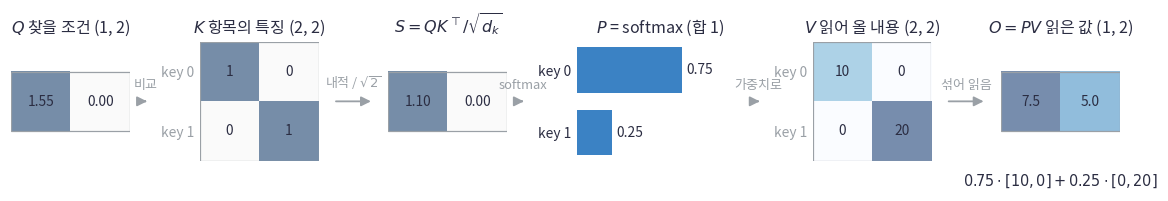

In [4]:
plot_attention_lookup(look_Q, look_K, look_S, look_P, look_V, look_O)

🔍 **확인** · 질문과 두 특징의 내적이 점수 `[log 3, 0]`이고, softmax를 지나면 `[0.75, 0.25]`입니다. 읽은 값은 첫 항목의 내용 `[10, 0]`을 0.75, 둘째 항목의 `[0, 20]`을 0.25만큼 섞은 `[7.5, 5]`입니다.
높은 가중치는 많이 읽었다는 계산상 의미입니다. 그것만으로 모델 판단의 인과적 설명이 증명되는 것은 아닙니다. $K$를 바꾸면 선택 비율이 달라지고, $V$를 바꾸면 같은 비율로 읽는 내용이 달라집니다.

### 🔍 같은 계산을 7의 패치에서 보면

7을 4×4 패치 49개로 자르고 패치 하나(화소 16개)를 토큰으로 봅니다. 학습 없이 화소 자체를 $Q=K=V$로 쓰면, 한 패치는 자기와 닮은 패치를 많이 읽습니다.

In [5]:
patch_query = int(np.argmax(patch_tokens.sum(axis=1)))            # 잉크가 가장 많은 패치를 query 로
patch_scores = patch_tokens @ patch_tokens[patch_query] / np.sqrt(16)   # (49,) Q = K = 화소 16개
patch_P = np.exp(patch_scores - patch_scores.max())
patch_P /= patch_P.sum()                                           # (49,) key 축에서 합 1
patch_O = patch_P @ patch_tokens                                   # (16,) 가중치로 섞어 읽은 패치
print("query 패치", patch_query, "(행, 열) =", divmod(patch_query, 7), "· 가장 큰 가중치", patch_P.max().round(3), "· 자기 자신에게", patch_P[patch_query].round(3))

query 패치 38 (행, 열) = (5, 3) · 가장 큰 가중치 0.069 · 자기 자신에게 0.069


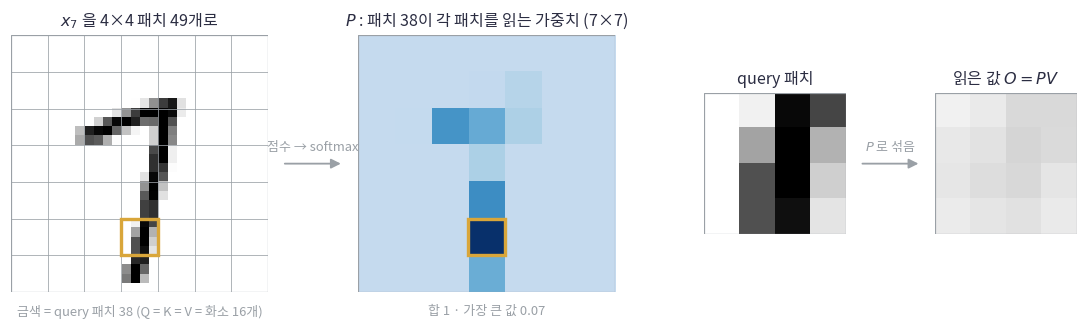

In [6]:
plot_patch_attention(mnist_7, 4, patch_query, patch_P.reshape(7, 7), patch_O.reshape(4, 4), patch_tokens[patch_query].reshape(4, 4))

🔍 **확인** · 가운데 7×7이 query 패치가 49개 패치 각각을 읽는 가중치입니다. 자기 자신과 잉크가 비슷하게 든 패치가 진하고, 빈 패치는 내적이 0이라 가중치가 작습니다. 읽은 값 $O$는 그 비율로 섞은 패치라 query와 닮았지만 조금 흐립니다.
학습된 attention은 $Q, K, V$를 선형 변환으로 만들어 "무엇을 닮음으로 볼지"를 바꿉니다. 아래 구현은 배치·mask까지 포함한 forward입니다.

In [7]:
def attention_forward(Q, K, V, allowed=None):
    assert Q.ndim == K.ndim == V.ndim == 3
    assert Q.shape[0] == K.shape[0] == V.shape[0]
    assert Q.shape[-1] == K.shape[-1] and K.shape[1] == V.shape[1]
    scale = np.sqrt(Q.shape[-1])
    scores = (Q @ K.swapaxes(-1, -2)) / scale
    if allowed is None:
        mask = np.ones(scores.shape, dtype=bool)
    else:
        mask = np.broadcast_to(np.asarray(allowed, dtype=bool), scores.shape)
    if not np.all(mask.any(axis=-1)):
        raise ValueError("각 query에는 읽을 수 있는 key가 최소 하나 필요합니다")
    masked = np.where(mask, scores, -np.inf)
    shifted = masked - masked.max(axis=-1, keepdims=True)
    exp_scores = np.exp(shifted)
    P = exp_scores / exp_scores.sum(axis=-1, keepdims=True)
    O = P @ V
    return O, (Q, K, V, P, mask, scale)

In [8]:
Q_hand = np.array([[[np.sqrt(2) * np.log(3), 0.]]])
K_hand = np.eye(2)[None]
V_hand = np.array([[[10., 0.], [0., 20.]]])
O_hand, hand_cache = attention_forward(Q_hand, K_hand, V_hand)
np.testing.assert_allclose(hand_cache[3], [[[0.75, 0.25]]])
np.testing.assert_allclose(O_hand, [[[7.5, 5.]]])
print("가중치:", hand_cache[3], "· 읽은 값:", O_hand)
patch_O_fn, patch_cache = attention_forward(patch_tokens[patch_query][None, None], patch_tokens[None], patch_tokens[None])
np.testing.assert_allclose(patch_O_fn[0, 0], patch_O); np.testing.assert_allclose(patch_cache[3][0, 0], patch_P)   # 위 패치 그림과 같은 값

가중치: [[[0.75 0.25]]] · 읽은 값: [[[7.5 5. ]]]


🔍 **확인** · `attention_forward`가 손계산의 `[0.75, 0.25]`, `[7.5, 5]`와 7 패치의 가중치·읽은 값을 그대로 냅니다. 캐시에는 backward에 필요한 $Q, K, V, P$와 mask, 나눈 수가 들어 있습니다.

## 🔑 2. 왜 $\sqrt{d_k}$로 나눕니까?

**이 절에서 가져갈 것:** 좌표가 독립이고 평균 0·분산 1이면 내적 $q\cdot k$의 분산은 $d_k$입니다. $\sqrt{d_k}$로 나누면 분산이 1이 되어, 비교 차원을 키워도 점수 차이가 지수적으로 커져 softmax가 한 위치에 몰리는 일을 막습니다.

> **용어** · **scaled dot-product**: 내적을 $\sqrt{d_k}$로 나눈 점수. "scaled"가 이 나눗셈입니다.

$q_i,k_i$가 서로 독립이고 평균 0·분산 1이라고 가정하면
$$\operatorname{Var}\left(\sum_{i=1}^{d_k}q_ik_i\right)=d_k.$$
곱의 평균은 0이고 $E[q_i^2k_i^2]=E[q_i^2]E[k_i^2]=1$입니다. 서로 다른 i의 교차항이 독립성으로 사라지므로 분산이 더해집니다. $\sqrt{d_k}$로 나누면 이 가정하의 분산이 1이 됩니다. 실제 학습된 Q·K가 항상 이 가정을 만족하는 것은 아닙니다.

지나치게 큰 점수 차이는 softmax를 한 위치에 몰리게 만들고, 많은 위치의 미분을 작게 만들 수 있습니다. 아래 실험은 분산 스케일을 재고, 같은 점수 8개를 나눈 것과 안 나눈 것의 softmax를 비교합니다.

In [9]:
rng = np.random.default_rng(81)
dimensions = [2, 8, 32, 128]
raw_variance, scaled_variance = [], []
for d in dimensions:
    q, k = rng.normal(size=(10000, d)), rng.normal(size=(10000, d))
    dots = np.sum(q * k, axis=-1)
    raw_variance.append(np.var(dots))
    scaled_variance.append(np.var(dots / np.sqrt(d)))
print("스케일 후 경험적 분산:", np.array(scaled_variance))

스케일 후 경험적 분산: [0.9853 1.0227 1.0103 0.9876]


In [10]:
rng_demo = np.random.default_rng(810)
demo_q, demo_keys = rng_demo.normal(size=128), rng_demo.normal(size=(8, 128))   # d_k = 128, key 8개
demo_raw = demo_keys @ demo_q                                                    # (8,) 나누지 않은 점수
demo_scaled = demo_raw / np.sqrt(128)
demo_p_raw = np.exp(demo_raw - demo_raw.max()); demo_p_raw /= demo_p_raw.sum()
demo_p_scaled = np.exp(demo_scaled - demo_scaled.max()); demo_p_scaled /= demo_p_scaled.sum()
print("점수 범위: 그대로", demo_raw.min().round(1), demo_raw.max().round(1), "· 나눈 뒤", demo_scaled.min().round(2), demo_scaled.max().round(2))

점수 범위: 그대로 -14.3 16.8 · 나눈 뒤 -1.26 1.48


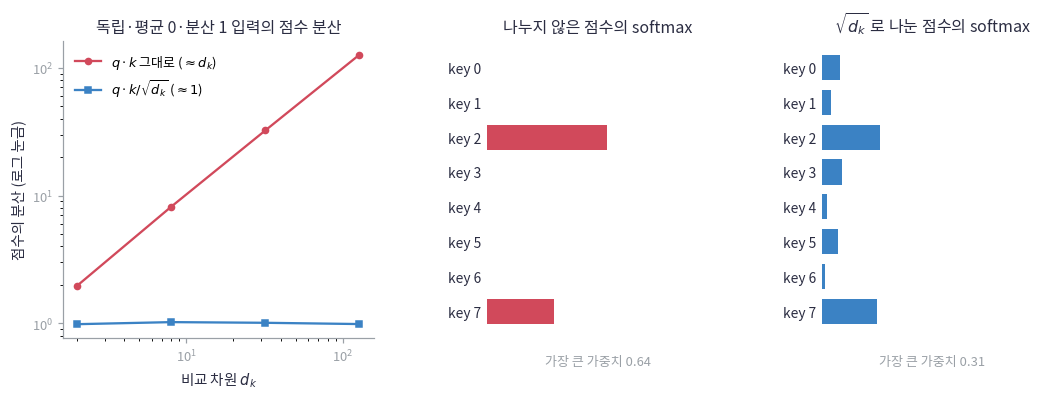

In [11]:
plot_score_variance(dimensions, raw_variance, scaled_variance, demo_p_raw, demo_p_scaled)

🔍 **확인** · 왼쪽에서 나누지 않은 점수의 분산은 $d_k$를 따라 커지고, 나눈 점수는 1 근처에 머뭅니다. 오른쪽에서 같은 8개 점수를 나누지 않으면 softmax가 한 key에 거의 몰리고, 나누면 여러 key에 퍼집니다.
몰린 softmax는 3절에서 볼 미분 $p_j(g_j-\sum g_ip_i)$가 대부분의 위치에서 0에 가까워 학습 신호가 약해집니다.

## 🔑 3. Softmax backward는 원소별 미분만으로 끝나지 않습니다

**이 절에서 가져갈 것:** softmax는 분모를 한 행 전체가 공유하므로 $s_j$ 하나를 바꾸면 그 행의 모든 $p_i$가 바뀝니다. 그래서 $ds_j=p_j(g_j-\sum_i g_ip_i)$이고, 코드로는 `P * (dP - (dP * P).sum(axis=-1, keepdims=True))`입니다.

> **용어** · **야코비안(Jacobian)** $\partial p_i/\partial s_j$: 출력 $i$를 입력 $j$로 미분한 값을 모은 행렬. softmax는 한 행에 대해 $(T_k, T_k)$ 행렬이지만, 상류 기울기와 곱한 결과만 필요하므로 행렬을 만들지 않고 한 줄로 계산합니다.

한 행 $p=softmax(s)$에 대해
$$\frac{\partial p_i}{\partial s_j}=p_i(\delta_{ij}-p_j).$$
$\delta_{ij}$는 i=j이면 1, 아니면 0입니다. 분모를 모든 위치가 공유해서 $s_j$ 하나가 다른 확률에도 영향을 줍니다. 행렬 전체를 만들지 않고 상류 기울기 $g=\partial L/\partial p$와 곱하면
$$ds_j=p_j\left(g_j-\sum_i g_ip_i\right).$$

따라서 `P * (dP - (dP*P).sum(axis=-1, keepdims=True))`입니다. BCE에서 보았던 sigmoid의 `p*(1-p)`만 곱하면 경쟁하는 다른 위치의 기여를 빠뜨립니다.

Attention 전체는 다음 행렬 미분을 역순으로 연결합니다.
$$dV=P^TdO,\quad dP=dOV^T,$$
$$dS=P\odot\left(dP-\sum_{key}dP\odot P\right),$$
$$dQ=dSK/\sqrt{d_k},\qquad dK=dS^TQ/\sqrt{d_k}.$$

$O=PV$는 03번의 affine이라 $dV$·$dP$가 나오고, $dP$를 softmax backward로 $dS$로 바꾼 뒤 $S=QK^\top/\sqrt{d_k}$의 두 입력으로 나눕니다.

mask로 제외한 위치는 점수에 의존하지 않으므로 $dS=0$입니다. mask는 학습 파라미터가 아닌 고정된 연결 허용 규칙으로 다룹니다.

아래는 $p=[0.25, 0.75]$, 상류 $g=[2, -1]$인 한 행의 손계산입니다.

In [12]:
sm_p = np.array([0.25, 0.75]); sm_g = np.array([2., -1.])
sm_jacobian = np.diag(sm_p) - np.outer(sm_p, sm_p)          # (2, 2) ∂p_i/∂s_j = p_i(δ_ij − p_j)
sm_ds = sm_g @ sm_jacobian                                  # (2,) g^T J
sm_ds_wrong = sm_g * sm_p * (1 - sm_p)                      # 원소별 오답
np.testing.assert_allclose(sm_ds, sm_p * (sm_g - np.sum(sm_g * sm_p)))   # 한 줄 공식과 같음
np.testing.assert_allclose(sm_ds, [9 / 16, -9 / 16])
print("Jacobian\n", sm_jacobian, "\nds =", sm_ds, "· 원소별 오답 =", sm_ds_wrong)

Jacobian
 [[ 0.1875 -0.1875]
 [-0.1875  0.1875]] 
ds = [ 0.5625 -0.5625] · 원소별 오답 = [ 0.375  -0.1875]


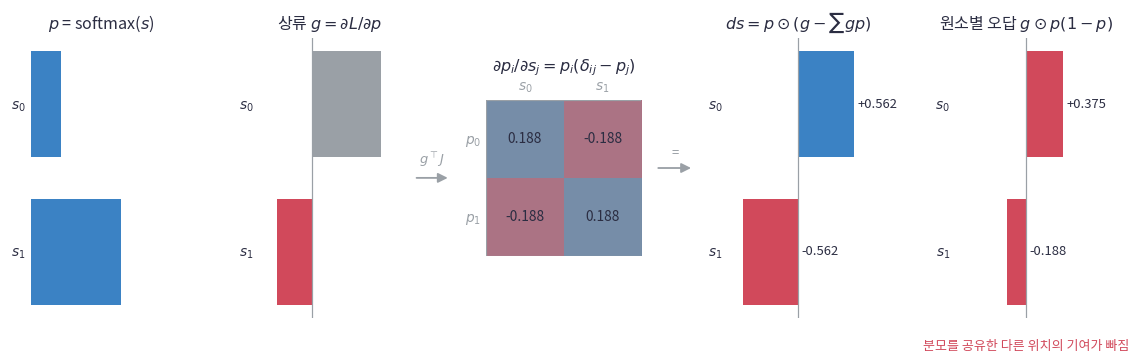

In [13]:
plot_softmax_backward(sm_p, sm_g, sm_jacobian, sm_ds, sm_ds_wrong)

🔍 **확인** · 야코비안의 대각선은 $p_i(1-p_i)$로 양수, 비대각선은 $-p_ip_j$로 음수입니다. 상류 $g$를 이 행렬에 곱한 $ds$는 $[9/16, -9/16]$이고 합이 0입니다. softmax 입력을 모두 같은 만큼 옮겨도 출력이 안 바뀌기 때문입니다.
오른쪽 원소별 오답은 비대각선을 무시해 크기도 다르고 합도 0이 아닙니다. 아래 구현은 이 한 줄 공식을 배치·mask와 함께 쓰고, 검산에서 손계산과 중심차분을 봅니다.

In [14]:
def softmax_backward(dP, P):
    return P * (dP - np.sum(dP * P, axis=-1, keepdims=True))


def attention_backward(dO, cache):
    Q, K, V, P, mask, scale = cache
    dV = P.swapaxes(-1, -2) @ dO
    dP = dO @ V.swapaxes(-1, -2)
    dS = np.where(mask, softmax_backward(dP, P), 0.)
    dQ = (dS @ K) / scale
    dK = (dS.swapaxes(-1, -2) @ Q) / scale
    return dQ, dK, dV


def check_attention_backward(candidate):
    rng = np.random.default_rng(82)
    errors = {}
    for masked in [False, True]:
        Q = rng.normal(size=(2, 2, 3))
        K = rng.normal(size=(2, 4, 3))
        V = rng.normal(size=(2, 4, 2))
        mask = np.array([[1, 1, 0, 0], [0, 1, 1, 1]], dtype=bool) if masked else None
        O, cache = attention_forward(Q, K, V, mask)
        G = rng.normal(size=O.shape)
        dQ, dK, dV = candidate(G, cache)
        scalar = lambda: float(np.sum(attention_forward(Q, K, V, mask)[0] * G))
        for name, value, grad in [("Q", Q, dQ), ("K", K, dK), ("V", V, dV)]:
            errors[f"mask={masked}/{name}"] = rel_error(grad, numerical_gradient(scalar, value))
            assert np.isfinite(errors[f"mask={masked}/{name}"]) and errors[f"mask={masked}/{name}"] < 2e-6, (masked, name, errors[f"mask={masked}/{name}"])
    return errors

In [15]:
np.testing.assert_allclose(softmax_backward(np.array([[2., -1.]]), np.array([[0.25, 0.75]])), [[9/16, -9/16]])
attention_errors = check_attention_backward(attention_backward)
print("Q·K·V와 mask 미분 최대 상대오차:", max(attention_errors.values()))

Q·K·V와 mask 미분 최대 상대오차: 5.101987596542411e-10


🔍 **확인** · 손계산 행의 `[9/16, -9/16]`이 나오고, mask가 있을 때와 없을 때 모두 $Q, K, V$ 미분이 중심차분과 $2\times10^{-6}$ 안에서 맞습니다.

## 🔑 4. Mask: 읽을 수 있는 위치를 수식에 넣기

**이 절에서 가져갈 것:** 읽으면 안 되는 key의 점수를 $-\infty$로 두면 지수가 0이 되어, 허용된 key 사이에서만 합이 1인 가중치가 됩니다. causal mask는 미래를, padding mask는 가짜 key를 금지하고 둘은 AND로 합칩니다.

> **용어**
>
> - **causal mask**: 질문 $q$가 $k>q$인 미래 key를 못 읽게 하는 규칙. 다음 토큰을 예측할 때 정답을 미리 보지 않게 합니다.
> - **padding mask**: 길이를 맞추려 덧붙인 빈칸(가짜 key)을 못 읽게 하는 규칙. 어느 위치가 가짜인지는 데이터가 정합니다.

`allowed[q,k]=True`이면 질문 q가 key k를 읽을 수 있습니다. **causal mask**는 미래 k>q를 금지합니다. **padding mask**는 빈칸을 채우기 위해 덧붙인 가짜 key를 금지합니다. 둘은 목적이 다르며 필요한 경우 AND로 결합합니다.

softmax를 계산한 다음 가중치를 그냥 0으로 만들면 행 합이 1이 아니게 됩니다. 여기서는 금지 점수를 $-\infty$로 놓아 지수값을 0으로 만든 뒤 허용 위치 사이에서 정규화합니다. 한 행 전체를 금지하면 정규화할 확률분포가 없으므로 명시적으로 오류를 냅니다.

패딩 query 자체의 출력·손실을 제외하는 일은 key mask만으로 해결되지 않습니다. 다음 Transformer의 목적함수에서 유효 query도 별도로 정해야 합니다.

아래는 길이 4에서 causal과 padding(마지막 key가 가짜)을 합친 mask이고, 미래 key를 바꿔도 과거 출력이 같은지 검산합니다.

In [16]:
T = 4
causal = np.arange(T)[None, :] <= np.arange(T)[:, None]
valid_keys = np.array([True, True, True, False])
combined = causal & valid_keys[None, :]
Qm, Km, Vm = [rng.normal(size=(1, T, 3)) for _ in range(3)]
Om, cm = attention_forward(Qm, Km, Vm, combined)
np.testing.assert_allclose(cm[3].sum(axis=-1), 1.)
assert np.all(cm[3][0][~combined] == 0)
# 과거 출력 0·1은 미래 위치 2·3의 K·V를 바꾸어도 같습니다.
K_changed, V_changed = Km.copy(), Vm.copy()
K_changed[:, 2:] += 100
V_changed[:, 2:] -= 100
O_changed, _ = attention_forward(Qm, K_changed, V_changed, combined)
np.testing.assert_allclose(Om[:, :2], O_changed[:, :2], atol=1e-12)
try:
    attention_forward(Qm, Km, Vm, np.zeros((T, T), dtype=bool))
except ValueError as error:
    print("예상한 입력 거부:", error)
else:
    raise AssertionError("전부 금지된 행을 검출하지 못했습니다")

예상한 입력 거부: 각 query에는 읽을 수 있는 key가 최소 하나 필요합니다


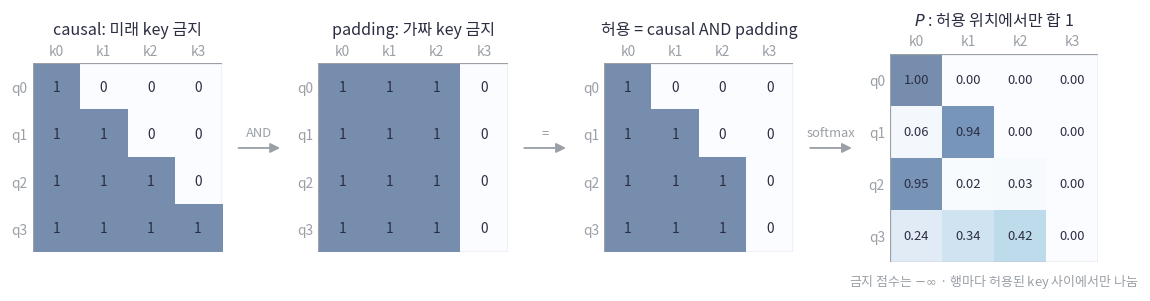

In [17]:
plot_masks(causal, valid_keys, combined, cm[3][0])

🔍 **확인** · causal은 대각선 아래(과거와 자기 자신)만 1, padding은 마지막 열만 0입니다. AND한 허용 표에서 q3 행은 k0–k2만 읽습니다. 오른쪽 $P$는 금지 칸이 정확히 0이고 행마다 허용된 칸의 합이 1입니다.
미래 위치 2·3의 $K, V$를 100만큼 바꿔도 과거 출력 0·1은 그대로이고, 전부 금지된 행은 오류로 거부됩니다.

## 🔑 5. 완성 학습: key에 붙은 이진 값을 찾아 답하기

**이 절에서 가져갈 것:** $Q=X_qW_q$, $K=X_kW_k$만 학습해도 "query와 같은 정체의 key를 골라 그 값을 읽는" 검색이 됩니다. backward는 CE → head → attention → 두 선형 변환으로 돌아가고, 위치별 affine의 파라미터 미분은 배치와 위치를 함께 합합니다.

> **용어** · **검색(retrieval) 문제**: 질문의 정체와 같은 정체의 key를 찾아 그 자리의 값을 답하는 문제. 값이 예제마다 무작위라 key의 정체를 외워 답할 수 없습니다.

네 key의 정체는 one-hot 4차원으로 주어집니다. 각 key에는 매 예제마다 무작위 이진 값이 붙고, 행 순서도 섞입니다. query가 지정한 key의 값을 맞힙니다. key의 정체를 외워 일정한 답을 내면 값이 매번 바뀌기 때문에 해결할 수 없습니다.

학습 가능한 계산은
$$Q=X_qW_q,\quad K=X_kW_k,\quad O=Attention(Q,K,V),\quad z=O_0W_o+b.$$
이번 V는 데이터에 주어진 값의 one-hot `(N,4,2)`를 그대로 씁니다. 다음 Transformer에서는 V도 학습된 변환으로 만듭니다. $W_q,W_k$는 `(4,4)`, $W_o$는 `(2,2)`, logits는 `(N,2)`입니다.

CE의 $dz=(softmax(z)-onehot(y))/N$에서 head→attention→Q/K 변환으로 돌아갑니다. 위치별 affine의 파라미터 미분은 **배치와 위치를 함께 합한 것**이므로, 앞 두 축을 한 줄로 펼쳐 행렬곱합니다. 이는 평균을 새로 적용하는 연산이 아닙니다.

아래는 예제 하나를 손으로 만든 것입니다.

In [18]:
ex_order = np.array([2, 0, 3, 1]); ex_bits = np.array([1, 0, 1, 1]); ex_query = 3   # 위치별 key 정체, 정체별 값, 질문 정체
ex_keys = np.eye(4)[ex_order]                               # (4, 4) 위치 i 의 key = 정체 ex_order[i] 의 one-hot
ex_values = np.eye(2)[ex_bits[ex_order]]                    # (4, 2) 위치 i 의 값 = 그 정체에 붙은 0/1 의 one-hot
ex_query_onehot = np.eye(4)[ex_query][None]                 # (1, 4)
ex_target_position = int(np.argmax(ex_order == ex_query))   # query 정체가 놓인 위치
ex_label = int(ex_bits[ex_query])                           # 정답 = 그 정체의 값
print("query 정체", ex_query, "→ 위치", ex_target_position, "· 그 위치의 값", ex_values[ex_target_position], "→ 정답", ex_label)

query 정체 3 → 위치 2 · 그 위치의 값 [0. 1.] → 정답 1


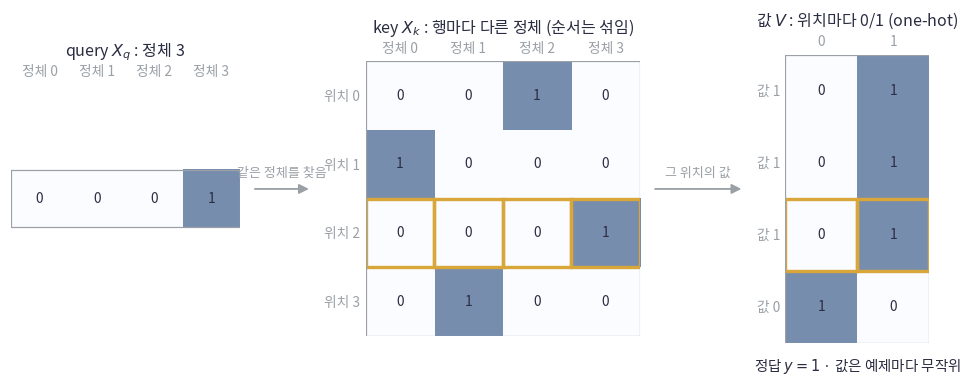

In [19]:
plot_retrieval_example(ex_query_onehot, ex_keys, ex_values, ex_order, ex_bits[ex_order], ex_label, ex_target_position)

🔍 **확인** · query의 정체 3이 놓인 위치는 두 번째 행(금색)이고, 그 자리의 값 one-hot이 `[0, 1]`이라 정답은 1입니다. attention이 이 문제를 풀려면 가중치 $P$가 금색 행에 몰려야 하고, 그러려면 $W_q, W_k$가 "같은 정체끼리 내적이 크게" 학습되어야 합니다.
아래 구현은 데이터 생성, CE, 손실·기울기, Adam, 초기화입니다.

In [20]:
def retrieval_data(n, seed):
    rng = np.random.default_rng(seed)
    keys = np.empty((n, 4, 4))
    values = np.empty((n, 4, 2))
    queries = np.empty((n, 1, 4))
    labels = np.empty(n, dtype=int)
    for row in range(n):
        order = rng.permutation(4)
        bits = rng.integers(0, 2, size=4)
        query = rng.integers(4)
        keys[row] = np.eye(4)[order]
        values[row] = np.eye(2)[bits[order]]
        queries[row, 0] = np.eye(4)[query]
        labels[row] = bits[query]
    return queries, keys, values, labels


def ce_loss(logits, y):
    z = logits - logits.max(axis=1, keepdims=True)
    logp = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
    grad = np.exp(logp)
    grad[np.arange(len(y)), y] -= 1
    return -logp[np.arange(len(y)), y].mean(), grad / len(y)


def retrieval_loss(Xq, Xk, V, y, p, backward_fn=attention_backward):
    Q, K = Xq @ p["Wq"], Xk @ p["Wk"]
    O, cache = attention_forward(Q, K, V)
    logits = O[:, 0] @ p["Wo"] + p["b"]
    loss, dz = ce_loss(logits, y)
    dO = (dz @ p["Wo"].T)[:, None, :]
    dQ, dK, dV = backward_fn(dO, cache)
    grads = {"Wo": O[:, 0].T @ dz, "b": dz.sum(axis=0),
             "Wq": Xq.reshape(-1, 4).T @ dQ.reshape(-1, 4),
             "Wk": Xk.reshape(-1, 4).T @ dK.reshape(-1, 4)}
    inputs = (dQ @ p["Wq"].T, dK @ p["Wk"].T, dV)
    return loss, logits, grads, cache[3], inputs


def adam_step(p, grads, state, step, lr=0.04):
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]
        v = 0.999 * v + 0.001 * grads[key] ** 2
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)


def init_retrieval(seed=85):
    rng = np.random.default_rng(seed)
    return {"Wq": rng.normal(size=(4, 4)) * 0.5, "Wk": rng.normal(size=(4, 4)) * 0.5,
            "Wo": rng.normal(size=(2, 2)) * 0.7, "b": np.zeros(2)}

In [21]:
probe_data = retrieval_data(2, 84)
probe_p = init_retrieval()
loss, _, grads, _, input_grads = retrieval_loss(*probe_data, probe_p)
scalar = lambda: float(retrieval_loss(*probe_data, probe_p)[0])
model_errors = {k: rel_error(grads[k], numerical_gradient(scalar, v)) for k, v in probe_p.items()}
for name, value, grad in zip(["Xq", "Xk", "V"], probe_data[:3], input_grads):
    model_errors[name] = rel_error(grad, numerical_gradient(scalar, value))
assert max(model_errors.values()) < 2e-6
print("검색 모델 전체 미분 최대 상대오차:", max(model_errors.values()))
probe_q, probe_k, probe_v, probe_y = probe_data
assert np.all(probe_k.sum(axis=-1) == 1) and np.all(probe_v.sum(axis=-1) == 1)   # 위 그림처럼 행마다 one-hot

검색 모델 전체 미분 최대 상대오차: 2.966572677205445e-08


🔍 **확인** · 네 파라미터와 세 입력의 미분이 모두 중심차분과 맞습니다. 이제 256개로 학습하고 별도 128개로 확인합니다.

In [22]:
train = retrieval_data(256, 86)
valid = retrieval_data(128, 87)
p = init_retrieval()
state = {k: (np.zeros_like(v), np.zeros_like(v)) for k, v in p.items()}
_, _, _, before_weights, _ = retrieval_loss(*valid, p)
history = {"step": [], "train": [], "valid": []}
for step in range(501):
    loss, logits, grads, _, _ = retrieval_loss(*train, p)
    if step % 50 == 0:
        valid_loss, valid_logits, _, after_weights, _ = retrieval_loss(*valid, p)
        history["step"].append(step)
        history["train"].append(loss)
        history["valid"].append(valid_loss)
    if step == 500:
        break
    adam_step(p, grads, state, step + 1)
accuracy = np.mean(valid_logits.argmax(axis=1) == valid[-1])
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f} · 정확도 {accuracy:.1%} (n=128)")
print("예시 query 정체:", valid[0][:4, 0].argmax(axis=-1), "· 행별 key 정체:", valid[1][:4].argmax(axis=-1))
assert accuracy > 0.95 and history["train"][-1] < 0.1

학습 CE 0.680324 → 0.001135
검증 CE 0.001138 · 정확도 100.0% (n=128)
예시 query 정체: [1 2 0 2] · 행별 key 정체: [[1 3 2 0]
 [1 2 0 3]
 [1 0 3 2]
 [0 1 2 3]]


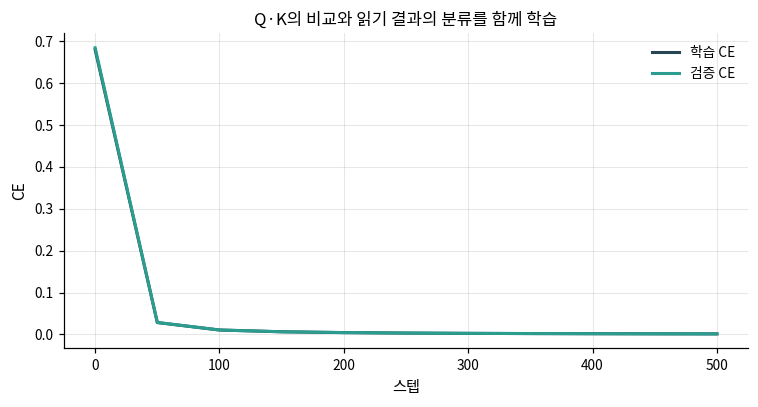

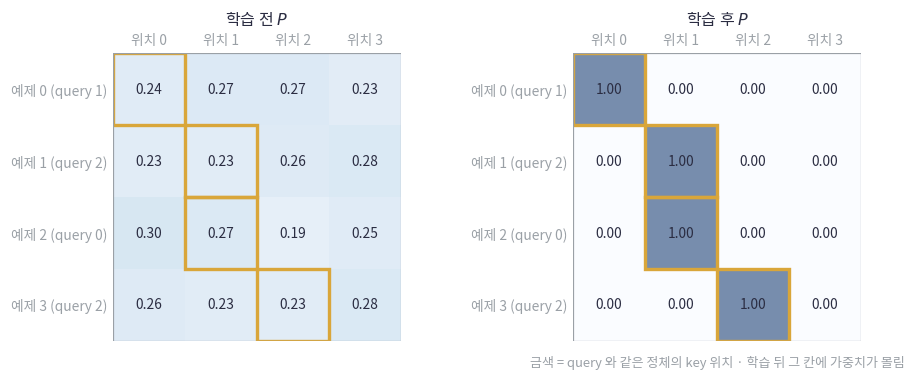

In [23]:
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="Q·K의 비교와 읽기 결과의 분류를 함께 학습", ylabel="CE")
valid_query_ids = valid[0][:4, 0].argmax(axis=-1)                                       # 예제 4개의 query 정체
target_positions = np.argmax(valid[1][:4].argmax(axis=-1) == valid_query_ids[:, None], axis=1)   # 같은 정체의 key 위치
plot_attention_weights(before_weights[:4, 0], after_weights[:4, 0], target_positions, valid_query_ids)

🔍 **확인** · 학습 전 가중치는 네 위치에 고루 퍼져 있고, 학습 뒤에는 금색 칸(query와 같은 정체의 key 위치)에 몰립니다. 검증 정확도가 95%를 넘습니다.
학습·검증은 같은 유한 생성 규칙에서 별도 추출했으며 일부 key/값 조합이 겹칠 수 있습니다. 이 결과는 작은 검색 규칙의 학습 확인입니다.

## 🔍 6. Self-attention과 cross-attention, 그리고 순서

> **용어**
>
> - **self-attention**: $Q$와 $K, V$의 원천이 같은 시퀀스. **cross-attention**: 원천이 다른 것. 값이나 가중치가 같다는 뜻은 아닙니다.
> - **순열 불변(permutation invariance)**: 항목의 순서를 바꿔도 결과가 같은 성질. 위치 정보가 없는 attention은 $K, V$의 공동 순열에 불변입니다.

Q의 원천과 K·V의 원천이 같은 시퀀스이면 **self-attention**, 서로 다르면 **cross-attention**입니다. 이번 검색 문제는 질문과 목록이 다른 원천이므로 cross-attention입니다.

위치 정보·mask가 없는 상태에서 K·V의 행을 **함께** 재배열하면 읽기 결과는 같습니다. 항목을 다른 순서로 나열했을 뿐이기 때문입니다. 순서가 의미 있는 언어 문제에서는 이 성질만으로 충분하지 않아 위치 정보를 넣습니다.

In [24]:
Q = valid[0] @ p["Wq"]
K = valid[1] @ p["Wk"]
V = valid[2]
permutation = np.array([2, 0, 3, 1])
original, _ = attention_forward(Q, K, V)
reordered, _ = attention_forward(Q, K[:, permutation], V[:, permutation])
np.testing.assert_allclose(original, reordered, atol=1e-12)
print("K·V의 공동 순열에 대한 출력 불변 검산 통과")

K·V의 공동 순열에 대한 출력 불변 검산 통과


🔍 **확인** · 학습한 모델에서 $K, V$의 행을 같은 순열로 섞어도 출력이 $10^{-12}$ 안에서 같습니다. 09번에서 위치 정보를 더하면 이 성질이 깨지고 순서를 읽을 수 있게 됩니다.

## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 나눈 점수 (1절)

`Q` $(N,T_q,d_k)$, `K` $(N,T_k,d_k)$에서 점수 $S=QK^\top/\sqrt{d_k}$ 한 줄을 채우세요. 배치 축을 유지하는 전치를 씁니다.

In [25]:
def exercise_scaled_scores(Q, K):
    assert Q.ndim == K.ndim == 3 and Q.shape[-1] == K.shape[-1]
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: S = Q 와 K 의 마지막 두 축 행렬곱을 sqrt(d_k) 로 나눈 값 (N, T_q, T_k)
    ### 힌트: K.swapaxes(-1, -2) 가 배치를 유지하는 전치입니다. d_k = Q.shape[-1]
    raise NotImplementedError
    return S

In [26]:
def check_scaled_scores(candidate):
    np.testing.assert_allclose(candidate(look_Q[None], look_K[None])[0], look_S)                  # 1절 손계산 [log 3, 0]
    rng_c = np.random.default_rng(88)
    Q_c, K_c = rng_c.normal(size=(2, 3, 5)), rng_c.normal(size=(2, 4, 5))
    S_c = candidate(Q_c, K_c)
    assert S_c.shape == (2, 3, 4)
    np.testing.assert_allclose(S_c[1, 2, 3], Q_c[1, 2] @ K_c[1, 3] / np.sqrt(5))                  # 한 칸을 내적으로 직접
    print("나눈 점수: 손계산·직접 내적과 일치합니다.")

run_check(check_scaled_scores, exercise_scaled_scores, hint="S = Q @ K.swapaxes(-1, -2) / np.sqrt(Q.shape[-1])")

☐ exercise_scaled_scores: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: S = Q @ K.swapaxes(-1, -2) / np.sqrt(Q.shape[-1])


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
S = Q @ K.swapaxes(-1, -2) / np.sqrt(Q.shape[-1])
```

</details>

### ✏️ 연습 B · key 축의 softmax (1절)

점수 `S` $(N,T_q,T_k)$에서 행마다 합이 1인 가중치 `P`를 만드는 두 줄을 채우세요. 가장 큰 값을 빼고 지수를 취해 넘침을 막습니다.

In [27]:
def exercise_softmax_rows(S):
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: E = exp(S − 행의 최댓값), P = E 를 마지막 축(key)의 합으로 나눈 값
    ### 힌트: S.max(axis=-1, keepdims=True), E.sum(axis=-1, keepdims=True)
    raise NotImplementedError
    return P

In [28]:
def check_softmax_rows(candidate):
    np.testing.assert_allclose(candidate(look_S[None])[0], [[0.75, 0.25]])                         # 1절 손계산
    P_c = candidate(np.random.default_rng(89).normal(size=(2, 3, 4)) * 5)
    np.testing.assert_allclose(P_c.sum(axis=-1), 1.)                                              # 행마다 합 1
    assert np.all(P_c > 0)
    np.testing.assert_allclose(candidate(patch_scores[None, None])[0, 0], patch_P)                 # 7 패치의 가중치
    print("key 축 softmax: 손계산·합 1·7 패치와 일치합니다.")

run_check(check_softmax_rows, exercise_softmax_rows, hint="E = np.exp(S - S.max(axis=-1, keepdims=True)); P = E / E.sum(axis=-1, keepdims=True)")

☐ exercise_softmax_rows: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: E = np.exp(S - S.max(axis=-1, keepdims=True)); P = E / E.sum(axis=-1, keepdims=True)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
E = np.exp(S - S.max(axis=-1, keepdims=True))
P = E / E.sum(axis=-1, keepdims=True)
```

</details>

### ✏️ 연습 C · softmax backward (3절)

가중치의 기울기 `dP`와 가중치 `P`에서 점수의 기울기 `dS`를 만드는 한 줄을 채우세요. 검사는 손계산 행과 attention 전체의 중심차분을 함께 봅니다.

In [29]:
def exercise_softmax_backward(dP, P):
    assert dP.shape == P.shape
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dS = P ⊙ (dP − key 축에서 (dP ⊙ P) 를 더한 값)
    ### 힌트: np.sum(dP * P, axis=-1, keepdims=True)
    raise NotImplementedError
    return dS

In [30]:
def check_softmax_backward(candidate):
    np.testing.assert_allclose(candidate(sm_g[None], sm_p[None])[0], sm_ds)                        # 3절 손계산 [9/16, −9/16]
    def backward_with(dO, cache):                                                                  # 후보를 attention backward 에 끼움
        Q, K, V, P, mask, scale = cache
        dS = np.where(mask, candidate(dO @ V.swapaxes(-1, -2), P), 0.)
        return (dS @ K) / scale, (dS.swapaxes(-1, -2) @ Q) / scale, P.swapaxes(-1, -2) @ dO
    check_attention_backward(backward_with)
    print("softmax backward: 손계산·attention 전체 중심차분과 일치합니다.")

run_check(check_softmax_backward, exercise_softmax_backward, hint="dS = P * (dP - np.sum(dP * P, axis=-1, keepdims=True))")

☐ exercise_softmax_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dS = P * (dP - np.sum(dP * P, axis=-1, keepdims=True))


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dS = P * (dP - np.sum(dP * P, axis=-1, keepdims=True))
```

</details>

### ✏️ 연습 D · 두 mask 합치기 (4절)

길이 `T`와 유효 key 표시 `valid_keys` $(T,)$에서 causal mask를 만들고 padding mask와 AND한 허용 표 $(T,T)$를 돌려주는 두 줄을 채우세요.

In [31]:
def exercise_combined_mask(T, valid_keys):
    assert valid_keys.shape == (T,) and valid_keys.dtype == bool
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: causal = key 번호 ≤ query 번호 인 (T, T) 불리언, combined = causal AND valid_keys 를 행마다 브로드캐스트
    ### 힌트: np.arange(T)[None, :] <= np.arange(T)[:, None], valid_keys[None, :]
    raise NotImplementedError
    return combined

In [32]:
def check_combined_mask(candidate):
    np.testing.assert_array_equal(candidate(4, valid_keys), combined)                             # 4절의 허용 표
    M = candidate(5, np.array([True, True, False, True, True]))
    assert M.shape == (5, 5) and not M[0, 1] and M[4, 0] and not M[4, 2] and M[3, 3]               # 미래 금지, 과거 허용, 가짜 key 금지
    print("mask 합치기: 4절의 허용 표와 일치합니다.")

run_check(check_combined_mask, exercise_combined_mask, hint="causal = np.arange(T)[None, :] <= np.arange(T)[:, None]; combined = causal & valid_keys[None, :]")

☐ exercise_combined_mask: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: causal = np.arange(T)[None, :] <= np.arange(T)[:, None]; combined = causal & valid_keys[None, :]


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
causal = np.arange(T)[None, :] <= np.arange(T)[:, None]
combined = causal & valid_keys[None, :]
```

</details>

### 🔍 완성 예제 · 검사기가 잡는 오답

아래 오답은 softmax를 sigmoid처럼 원소별로만 미분합니다. 3절의 검사기가 거부하는 것을 확인합니다.

In [33]:
def wrong_elementwise_softmax(dO, cache):
    Q, K, V, P, mask, scale = cache
    dP = dO @ V.swapaxes(-1, -2)
    dS = dP * P * (1 - P)
    return (dS @ K) / scale, (dS.swapaxes(-1, -2) @ Q) / scale, P.swapaxes(-1, -2) @ dO

In [34]:
try:
    check_attention_backward(wrong_elementwise_softmax)
except AssertionError:
    print("의도적 오답 검출: softmax의 다른 위치 기여 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")

의도적 오답 검출: softmax의 다른 위치 기여 누락


### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** Q·K·V의 역할과 self/cross의 차이를 구분할 수 있나요? → 1·6절
- **수식:** softmax의 전체 분모를 미분하고 Q·K·V로 돌아가는 식을 쓸 수 있나요? → 3절
- **구현:** 마지막 두 축의 전치·배치 행렬곱·key 축 정규화를 맞출 수 있나요? → 1절
- **변형:** key 수를 4에서 3으로 바꾸면 one-hot 차원·$W_q, W_k$·reshape의 숫자가 어떻게 바뀌는지 적고, query가 2개일 때 손실 평균 축을 말할 수 있나요? → 5절

다음은 [09 Transformer](09_transformer.ipynb)입니다. 이 부품에 위치 정보·잔차·정규화·FFN을 붙여 블록으로 쌓습니다.

📎 [Transformer 원 논문의 3.2절](https://arxiv.org/abs/1706.03762)에 scaled dot-product attention과 여러 head의 결합이 정의되어 있습니다. 이 노트북은 하나의 head를 독립적으로 구현했습니다.